In [1]:
import torch

import numpy as np

from utils import get_device
from classifier_common import Model, draw_images_with_score, load_images, IMG_WIDTH

In [ ]:
device = get_device()
print(device)

In [ ]:
model_8 = Model(out_dim=8).to(device)
model_15 = Model(out_dim=15).to(device)

model_8.load_state_dict(
    torch.load("models/classifier_d8.model", map_location=torch.device(device))
)
model_15.load_state_dict(
    torch.load("models/classifier_d15.model", map_location=torch.device(device))
)

In [ ]:
RAW_DATASET_NAME = "teddy-bear"
CLEAN_DATASET_NAME = "teddy_bear"


def clean_dataset(raw_name, clean_name, adam_label, artur_label, p=0.9995):
    raw_path = f"datasets/{raw_name}.bin"
    clean_path = f"clean_datasets/{clean_name}.npy"

    all_imgs = load_images(raw_path)
    imgs_tensor = (
        torch.tensor(all_imgs)
        .float()
        .reshape(len(all_imgs), 1, IMG_WIDTH, IMG_WIDTH)
        .to(device)
    )

    dataset = torch.utils.data.TensorDataset(imgs_tensor)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=False)

    bad_img, good_img = [], []

    model_8.eval()
    model_15.eval()
    with torch.no_grad():
        for (imgs,) in dataloader:
            imgs = imgs.to(device)

            quality_adam = model_8(imgs).cpu().squeeze().numpy()[:, adam_label]
            quality_artur = model_15(imgs).cpu().squeeze().numpy()[:, artur_label]

            for img, q_adam, q_artur in zip(imgs, quality_adam, quality_artur):
                img = img.reshape(IMG_WIDTH, IMG_WIDTH).cpu()
                min_quality = min(q_adam, q_artur)
                if min_quality < p:
                    bad_img.append((img, min_quality))
                else:
                    good_img.append((img, min_quality))

    print(
        f"Filtered out {len(bad_img)} / {len(all_imgs)} = {100 * len(bad_img) / len(all_imgs):.2f}% of data set "
    )

    good_to_save = np.array([img.cpu().numpy().flatten() for img, _ in good_img])
    good_to_save = ((good_to_save + 1.0) / 2.0) * 255.0

    with open(clean_path, "wb") as file:
        np.save(file, good_to_save.astype(np.uint8))

    return bad_img, good_img


In [6]:
bad_teddy, good_teddy = clean_dataset(
    RAW_DATASET_NAME, CLEAN_DATASET_NAME, 0, 0, 0.9995
)

Filtered out 118450 / 157583 = 75.17% of data set 


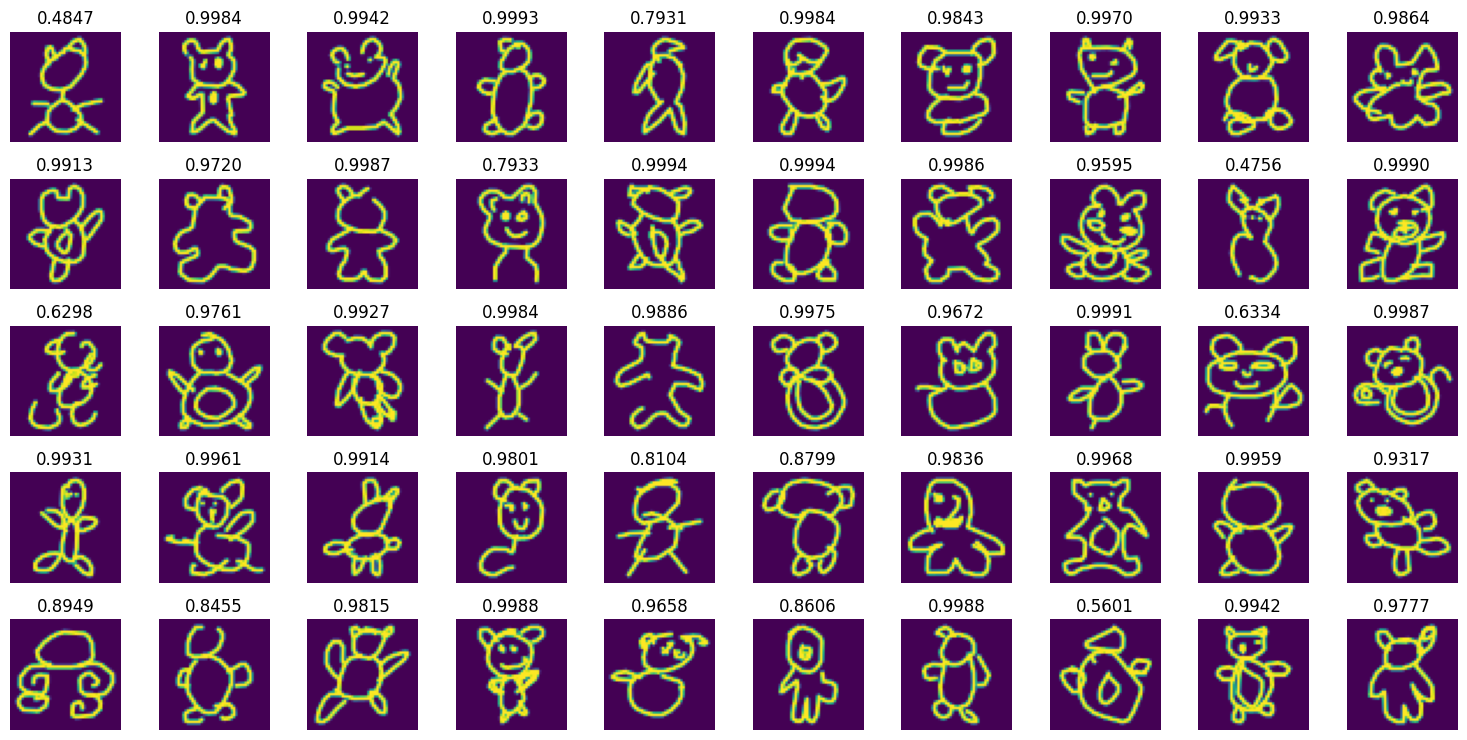

In [9]:
draw_images_with_score(bad_teddy)

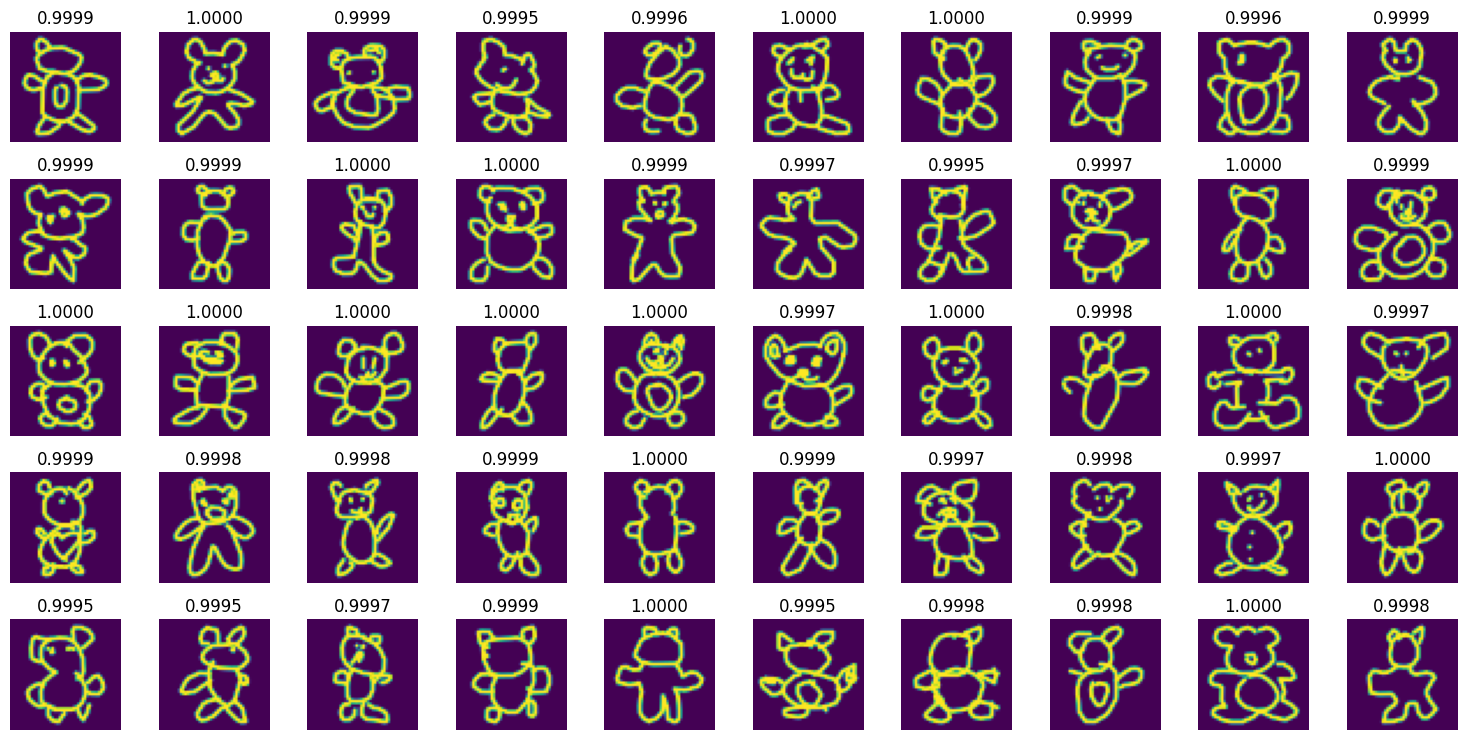

In [8]:
draw_images_with_score(good_teddy)